# **Telco Customer Churn Project**

## 📝 Project Description
The objective of this project is to analyze customer data and build a Machine Learning model to predict customer churn. "Churn" refers to whether a customer will cancel their subscription (**Yes**) or continue using the service (**No**). Predicting churn helps businesses take proactive steps to improve customer retention.

## 💾 Dataset Overview
This project uses the industry-standard **IBM Telco Customer Churn** dataset from Kaggle.
* **Size:** Over 7,000 customer records.
* **Features:** Includes demographic data, account details (e.g., contract type, monthly charges, payment method), and subscribed services.
* **Target Variable:** `Churn` (Binary: Yes/No).

## 🛠️ Tools & Libraries
* **Data Manipulation:** `pandas`
* **Data Visualization:** `matplotlib`, `seaborn`
* **Machine Learning:** `scikit-learn` (will be used for modeling)

### 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load the Dataset

In [2]:
file_path = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

### 3. Data Inspection

In [3]:
print("First 5 rows of the Data:")
print("***" * 25)
print(df.head())
print("***" * 25)
print("Dataset structure, missing values, and data types")
print(df.info())

First 5 rows of the Data:
***************************************************************************
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic  

### 4. Data Cleaning & Preprocessing

In [4]:
df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

df['TotalCharges'].fillna(0)

print("\nMissing values after cleaning:", df['TotalCharges'].isnull().sum())
print("TotalCharges data type is now:", df['TotalCharges'].dtype)

Missing values in TotalCharges: 11

Missing values after cleaning: 11
TotalCharges data type is now: float64


### 5. Exploratory Data Analysis (EDA)

####  1. Churn by Contract Type


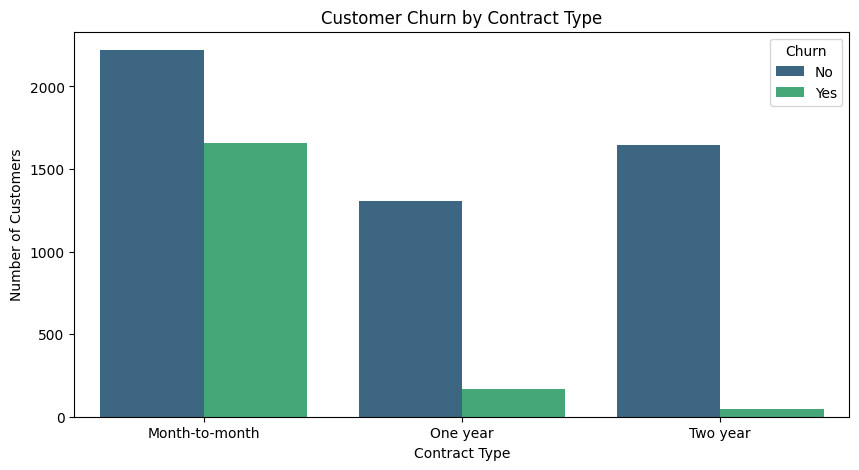

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

####  2. Churn by Monthly Charges


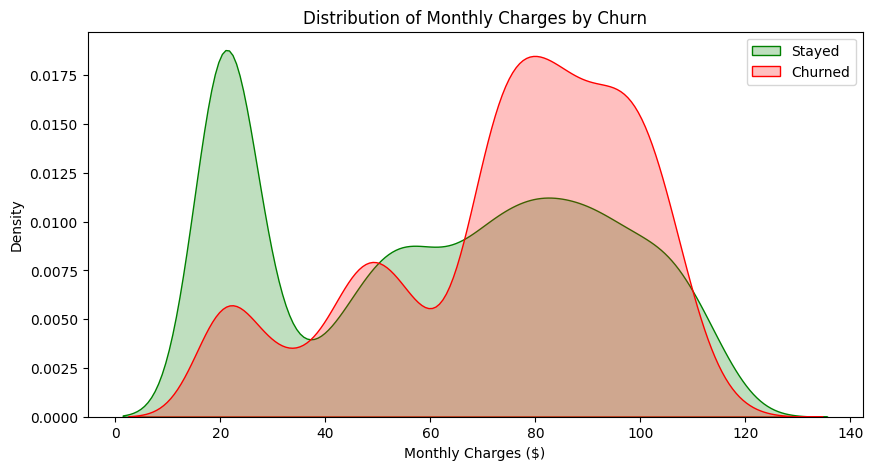

In [6]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['Churn'] == 'No']['MonthlyCharges'], label='Stayed', fill=True, color='green')
sns.kdeplot(data=df[df['Churn'] == 'Yes']['MonthlyCharges'], label='Churned', fill=True, color='red')
plt.title('Distribution of Monthly Charges by Churn')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.legend()
plt.show()

### 6. Data Encoding & Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

print(f"Training data size: {X_train.shape[0]} customers")
print(f"Testing data size: {X_test.shape[0]} customers")
print(f"Number of features (columns) the model will learn from: {X_train.shape[1]}")

Training data size: 5634 customers
Testing data size: 1409 customers
Number of features (columns) the model will learn from: 30


### 7. Model Building & Evaluation

Fitting 3 folds for each of 81 candidates, totalling 243 fits

Best Parameters found: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Optimized Model Accuracy: 76.37%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1035
           1       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409


--- Optimized Model Evaluation ---
Classification Report:


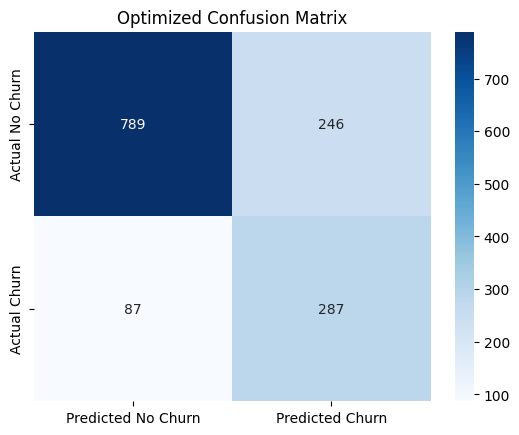

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=3, n_jobs=-1, scoring='recall', verbose=2)

grid_search.fit(X_train, y_train)

print("\nBest Parameters found:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
print(f"Optimized Model Accuracy: {accuracy_score(y_test, y_pred_best) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_best))
print("\n--- Optimized Model Evaluation ---")
print("Classification Report:")
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Optimized Confusion Matrix')
plt.show()

### 8.Extract Datasset

In [11]:
from google.colab import files

results_df = X_test.copy()

results_df['Actual_Churn'] = y_test
results_df['Predicted_Churn'] = y_pred_best

csv_filename = 'Optimized_Churn_Predictions.csv'
results_df.to_csv(csv_filename, index=False)

print(f"Data successfully saved to {csv_filename}!")

files.download(csv_filename)

Data successfully saved to Optimized_Churn_Predictions.csv!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>